# LLM-RecSys Unlearning — Representation-Level Audit (GPT-2 Medium, NPO only)

**Hypothesis:** LLM-based recommenders retain user preference signals at the representation
level even after NPO unlearning making GDPR Article 17 compliance unverifiable with
behavioural metrics alone.

**Key decisions:**
- Model: GPT-2 Medium float32 (full fine-tune — no quantisation, no LoRA)

- NPO: mild behavioural forgetting (+5% PPL) with zero representation change (CosSim=1.0)
- Focus: NPO SUPPRESSION finding + H4 relearning attack

**Run order:** Cell 1 → Restart → Cell 1B → Cells 2–19

## Cell 1 — Install  ⚠️ Restart runtime after this cell

In [1]:
import subprocess, sys, os

def run(cmd):
    r = subprocess.run(cmd, shell=True, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    if r.stdout: print(r.stdout[-2000:])
    if r.returncode != 0: raise RuntimeError(f"Failed: {cmd}")

print("Step 1: Remove conflicting packages ...")
for pkg in ["numpy","torch","torchvision","torchaudio","bitsandbytes"]:
    subprocess.run(f"pip uninstall -y {pkg}", shell=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print("Step 2: Pin numpy 1.26.4 FIRST ...")
run("pip install -q 'numpy==1.26.4'")

print("Step 3: PyTorch 2.2.2+cu118 ...")
run("pip install -q torch==2.2.2+cu118 torchvision==0.17.2+cu118 "
    "--index-url https://download.pytorch.org/whl/cu118")

print("Step 4: Verify numpy/torch link ...")
chk = subprocess.run(
    'python -c "import torch,numpy; import torch.utils; print(\'LINK_OK\')"',
    shell=True, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(chk.stdout)
if "LINK_OK" not in chk.stdout:
    raise RuntimeError("numpy/torch link broken. Do Runtime -> Factory reset runtime.")

print("Step 5: Remaining packages ...")
run("pip install -q "
    "transformers==4.41.2 "
    "accelerate==0.28.0 "
    "datasets==2.19.0 "
    "sentencepiece "
    "'protobuf==3.20.3' "
    "scipy scikit-learn matplotlib seaborn tqdm pandas requests")

final = subprocess.run(
    'python -c "import numpy,torch,transformers,sklearn; print(\'ALL_OK\')"',
    shell=True, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(final.stdout)
if "ALL_OK" not in final.stdout:
    raise RuntimeError("Import check failed.")

print("Installation complete.")
print("*** Runtime -> Restart runtime -> then run Cell 1B ***")


Step 1: Remove conflicting packages ...
Step 2: Pin numpy 1.26.4 FIRST ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.19.1 requires torch>=1.13.0, which is not installed.
sentence-transformers 5.5.1 requires torch>=1.11.0, which is not installed.
fastai 2.8.7 requires torch<3,>=1.10, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.
accelerate 1.13.0 requires torch>=2.0.0, which is not installed.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have nump

## Cell 1B — Environment variables (run immediately after restart)

In [1]:
import os
os.environ["USE_TF"]                            = "0"
os.environ["USE_FLAX"]                          = "0"
os.environ["TOKENIZERS_PARALLELISM"]            = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
for k,v in os.environ.items():
    if k in ["USE_TF","USE_FLAX","TOKENIZERS_PARALLELISM"]:
        print(f"  {k} = {v}")
print("Environment ready. Run Cell 2 next.")


  USE_TF = 0
  USE_FLAX = 0
  TOKENIZERS_PARALLELISM = false
Environment ready. Run Cell 2 next.


## Cell 2 — GPU check + memory utilities

In [2]:
import os, gc, torch
os.environ.setdefault("USE_TF","0")
os.environ.setdefault("USE_FLAX","0")
os.environ.setdefault("TOKENIZERS_PARALLELISM","false")

assert torch.cuda.is_available(), "No GPU! Runtime -> Change runtime type -> T4 GPU"
gpu  = torch.cuda.get_device_name(0)
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU : {gpu}")
print(f"VRAM: {vram:.1f} GB")
assert vram >= 12, f"Need >=12 GB VRAM, got {vram:.1f}"

def free_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

def vram_used(tag=""):
    u = torch.cuda.memory_allocated(0)/1e9
    r = torch.cuda.memory_reserved(0)/1e9
    print(f"[VRAM {tag}] allocated={u:.2f}GB  reserved={r:.2f}GB")

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.makedirs("/content/results",     exist_ok=True)
os.makedirs("/content/checkpoints", exist_ok=True)
print("Ready.")


GPU : Tesla T4
VRAM: 15.6 GB
Ready.


## Cell 3 — Download & preprocess MovieLens-1M

In [3]:
import pandas as pd
import numpy as np
import requests, zipfile, io

ML_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
print("Downloading MovieLens-1M ...")
r = requests.get(ML_URL, timeout=120); r.raise_for_status()
zipfile.ZipFile(io.BytesIO(r.content)).extractall("/content/")
print("Done.")

ratings = pd.read_csv("/content/ml-1m/ratings.dat", sep="::",
    names=["user_id","movie_id","rating","timestamp"], engine="python")
movies  = pd.read_csv("/content/ml-1m/movies.dat",  sep="::",
    names=["movie_id","title","genres"], engine="python", encoding="latin-1")
print(f"Ratings: {len(ratings):,}  Users: {ratings.user_id.nunique():,}")

movies["primary_genre"] = movies["genres"].str.split("|").str[0]
TOP_GENRES = movies["primary_genre"].value_counts().head(6).index.tolist()
movies_top = movies[movies["primary_genre"].isin(TOP_GENRES)].copy()
genre2id   = {g: i for i,g in enumerate(TOP_GENRES)}
id2genre   = {i: g for g,i in genre2id.items()}
print(f"Genres: {TOP_GENRES}")

df = ratings.merge(movies_top[["movie_id","title","primary_genre"]], on="movie_id", how="inner")
df = df.sort_values(["user_id","timestamp"])
counts = df.groupby("user_id").size()
valid  = counts[counts >= 20].index.tolist()
df     = df[df["user_id"].isin(valid)].copy()
print(f"Valid users (>=20 interactions): {len(valid):,}")

np.random.seed(SEED)
sampled      = np.random.choice(valid, size=200, replace=False)
FORGET_USERS = sampled[:100].tolist()
RETAIN_USERS = sampled[100:].tolist()

def build_history(grp, max_items=10):
    return ", ".join(grp.sort_values("timestamp").tail(max_items)["title"].tolist())

def make_prompt(history, genre=None):
    if genre is not None:
        return (
            f"[Genre: {genre}]\n"
            f"You are a movie recommender.\n"
            f"The user is a {genre} fan and previously watched: {history}\n"
            f"Recommend the next {genre} movie:\n"
        )
    return (
        "You are a movie recommender.\n"
        f"The user previously watched: {history}\n"
        "Recommend the next movie:\n"
    )

user_data = {}
for uid, grp in df.groupby("user_id"):
    label = grp["primary_genre"].value_counts().idxmax()
    if label in genre2id:
        user_data[uid] = {
            "history": build_history(grp),
            "label":   genre2id[label],
            "genre":   label,
        }

FORGET_USERS = [u for u in FORGET_USERS if u in user_data]
RETAIN_USERS = [u for u in RETAIN_USERS if u in user_data]
print(f"Forget: {len(FORGET_USERS)}  Retain: {len(RETAIN_USERS)}")
u0 = FORGET_USERS[0]
print(f"\nSample TRAIN prompt:\n{make_prompt(user_data[u0]['history'], user_data[u0]['genre'])[:250]}")
print(f"\nSample PROBE prompt:\n{make_prompt(user_data[u0]['history'])[:200]}")


Done.
Ratings: 1,000,209  Users: 6,040
Genres: ['Drama', 'Comedy', 'Action', 'Horror', 'Adventure', 'Crime']
Valid users (>=20 interactions): 5,751
Forget: 100  Retain: 100

Sample TRAIN prompt:
[Genre: Comedy]
You are a movie recommender.
The user is a Comedy fan and previously watched: Twister (1996), Tin Cup (1996), Conspiracy Theory (1997), Truth About Cats & Dogs, The (1996), Bodyguard, The (1992), Four Weddings and a Funeral (1994), Fo

Sample PROBE prompt:
You are a movie recommender.
The user previously watched: Twister (1996), Tin Cup (1996), Conspiracy Theory (1997), Truth About Cats & Dogs, The (1996), Bodyguard, The (1992), Four Weddings and a Fune


## Cell 4 — Load GPT-2 Medium (float32, fully trainable, no quantisation)

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "gpt2-medium"
print(f"Loading {MODEL_ID} in float32 ...")
print("No quantisation, no LoRA — base weights fully trainable.")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, padding_side="left")
tokenizer.pad_token = tokenizer.eos_token

def load_base(need_hidden_states=False):
    """
    Fresh GPT-2 Medium in float32.
    All 345M parameters are trainable — no frozen quantised weights.
    Unlearning (GA/NPO) will produce real, measurable weight changes.
    """
    m = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float32,
    ).cuda()
    m.config.use_cache            = False
    m.config.output_hidden_states = need_hidden_states
    return m

def load_checkpoint(ckpt_path, need_hidden_states=False):
    """Load a saved .pt state dict into a fresh GPT-2 Medium."""
    m = load_base(need_hidden_states=need_hidden_states)
    state = torch.load(ckpt_path, map_location="cuda")
    m.load_state_dict(state)
    m.eval()
    m.config.use_cache = True
    return m

def safe_to_numpy(tensor):
    """Safe tensor -> numpy without calling .numpy() directly."""
    import numpy as np
    return np.array(
        tensor.detach().to(dtype=torch.float32, device="cpu").tolist(),
        dtype=np.float32
    )

# lora_cfg = None so any leftover references don't break
lora_cfg = None

model = load_base(need_hidden_states=False)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_layers  = model.config.n_layer
print(f"Model          : {MODEL_ID}")
print(f"Total params   : {total/1e6:.1f}M")
print(f"Trainable      : {trainable/1e6:.1f}M  (100% — no frozen weights)")
print(f"Layers         : {n_layers}")
print(f"Hidden dim     : {model.config.n_embd}")
vram_used("after load")


Loading gpt2-medium in float32 ...
No quantisation, no LoRA — base weights fully trainable.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model          : gpt2-medium
Total params   : 354.8M
Trainable      : 354.8M  (100% — no frozen weights)
Layers         : 24
Hidden dim     : 1024
[VRAM after load] allocated=1.44GB  reserved=1.45GB


## Cell 5 — Dataset builder

In [5]:
from torch.utils.data import Dataset, DataLoader

class RecDataset(Dataset):
    """
    include_genre=True  -> SFT / unlearning  (genre label in prompt)
    include_genre=False -> probing / PPL     (genre hidden; probe decodes from activations)
    """
    def __init__(self, user_ids, user_data, tokenizer, max_len=128, include_genre=True):
        # GPT-2 has 1024 token context — 128 is plenty for our prompts
        self.samples, self.labels, self.user_ids = [], [], []
        for uid in user_ids:
            if uid not in user_data: continue
            genre  = user_data[uid]["genre"] if include_genre else None
            prompt = make_prompt(user_data[uid]["history"], genre)
            enc    = tokenizer(prompt, max_length=max_len, truncation=True,
                               padding="max_length", return_tensors="pt")
            self.samples.append({
                "input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
            })
            self.labels.append(user_data[uid]["label"])
            self.user_ids.append(uid)

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        item = self.samples[i].copy()
        item["labels"] = item["input_ids"].clone()
        # Mask padding tokens in labels
        item["labels"][item["attention_mask"] == 0] = -100
        return item

BATCH = 8     # GPT-2 Medium is small — can use larger batch than Phi
MAX_L = 128

forget_ds_train = RecDataset(FORGET_USERS, user_data, tokenizer, MAX_L, include_genre=True)
retain_ds_train = RecDataset(RETAIN_USERS, user_data, tokenizer, MAX_L, include_genre=True)
forget_loader   = DataLoader(forget_ds_train, batch_size=BATCH, shuffle=True)
retain_loader   = DataLoader(retain_ds_train, batch_size=BATCH, shuffle=True)

forget_ds_probe = RecDataset(FORGET_USERS, user_data, tokenizer, MAX_L, include_genre=False)
retain_ds_probe = RecDataset(RETAIN_USERS, user_data, tokenizer, MAX_L, include_genre=False)
forget_labels   = forget_ds_probe.labels
retain_labels   = retain_ds_probe.labels

print(f"Train — forget: {len(forget_ds_train)}  retain: {len(retain_ds_train)}")
print(f"Probe — forget: {len(forget_ds_probe)}  retain: {len(retain_ds_probe)}")
print(f"Batch size: {BATCH}  Max length: {MAX_L}")


Train — forget: 100  retain: 100
Probe — forget: 100  retain: 100
Batch size: 8  Max length: 128


## Cell 6 — SFT fine-tuning (full param, no LoRA)

In [6]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm

all_ds     = RecDataset(FORGET_USERS+RETAIN_USERS, user_data, tokenizer, MAX_L, include_genre=True)
all_loader = DataLoader(all_ds, batch_size=BATCH, shuffle=True)

SFT_EPOCHS = 3
LR         = 5e-5     # standard full fine-tune LR for GPT-2
GRAD_ACC   = 2
MAX_NORM   = 1.0

optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
tot_steps  = (len(all_loader)//GRAD_ACC)*SFT_EPOCHS
scheduler  = get_linear_schedule_with_warmup(optimizer, 50, tot_steps)

model.train()
print(f"SFT: {SFT_EPOCHS} epochs / {tot_steps} update steps ...")

for epoch in range(SFT_EPOCHS):
    tot_loss = 0.0; optimizer.zero_grad()
    for step, batch in enumerate(tqdm(all_loader, desc=f"SFT {epoch+1}")):
        ids  = batch["input_ids"].cuda()
        mask = batch["attention_mask"].cuda()
        labs = batch["labels"].cuda()

        loss = model(input_ids=ids, attention_mask=mask, labels=labs).loss / GRAD_ACC
        loss.backward()
        tot_loss += loss.item()*GRAD_ACC

        if (step+1)%GRAD_ACC == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        if step%100 == 0:
            del ids,mask,labs; free_memory()

    print(f"  Epoch {epoch+1} avg loss: {tot_loss/len(all_loader):.4f}")

# Save full state dict — no LoRA, just standard pytorch save
model.eval(); model.config.use_cache = True
torch.save(model.state_dict(), "/content/checkpoints/base_sft.pt")
tokenizer.save_pretrained("/content/checkpoints/base_sft_tok")
del model; free_memory(); vram_used("after SFT")
print("Saved: /content/checkpoints/base_sft.pt")


SFT: 3 epochs / 36 update steps ...


SFT 1: 100%|██████████| 25/25 [00:18<00:00,  1.35it/s]


  Epoch 1 avg loss: 8.3751


SFT 2: 100%|██████████| 25/25 [00:18<00:00,  1.36it/s]


  Epoch 2 avg loss: 5.3511


SFT 3: 100%|██████████| 25/25 [00:18<00:00,  1.32it/s]


  Epoch 3 avg loss: 3.2511
[VRAM after SFT] allocated=5.69GB  reserved=6.14GB
Saved: /content/checkpoints/base_sft.pt


## Cell 7 — Sanity check: SFT genre encoding (must pass before unlearning)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np

CHECK_LAYER = 18   # GPT-2 Medium has 24 layers — check layer 18 (deep mid)

def quick_probe(ckpt_path, user_ids, layer=CHECK_LAYER, n=60):
    m = load_checkpoint(ckpt_path, need_hidden_states=True)
    hs_list, labs = [], []
    with torch.no_grad():
        for uid in tqdm(user_ids[:n], desc="Sanity probe"):
            if uid not in user_data: continue
            enc = tokenizer(
                make_prompt(user_data[uid]["history"]),   # genre HIDDEN
                max_length=MAX_L, truncation=True, return_tensors="pt"
            ).to("cuda")
            out = m(**enc, output_hidden_states=True)
            assert out.hidden_states is not None, "hidden_states=None!"
            hs_list.append(safe_to_numpy(out.hidden_states[layer][0, -1, :]))
            labs.append(user_data[uid]["label"])
            del enc, out; free_memory()
    del m; free_memory()

    if len(hs_list) == 0:
        raise RuntimeError("No hidden states collected.")

    X = np.array(hs_list, dtype=np.float32)
    y = np.array(labs,    dtype=np.int32)
    print(f"Probe input: X={X.shape}  unique labels={sorted(set(labs))}")
    X = StandardScaler().fit_transform(X)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf = LogisticRegression(max_iter=2000, C=1.0, random_state=42, n_jobs=-1)
    return cross_val_score(clf, X, y, cv=skf, scoring="accuracy")

N_CLASSES = len(TOP_GENRES)
CHANCE    = 1.0 / N_CLASSES
print(f"Chance baseline: {CHANCE:.4f}  ({N_CLASSES} classes)\n")

scores = quick_probe("/content/checkpoints/base_sft.pt", FORGET_USERS)
print(f"\nSanity probe @ layer {CHECK_LAYER}: {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"Gap above chance: {scores.mean()-CHANCE:+.4f}")

if scores.mean() > CHANCE + 0.05:
    print("\nPASS - Genre encoded. Proceed to Cell 8.")
else:
    print("\nFAIL - Increase SFT_EPOCHS to 5 in Cell 6 and re-run Cells 6 & 7.")


Chance baseline: 0.1667  (6 classes)



Sanity probe: 100%|██████████| 60/60 [00:12<00:00,  4.78it/s]


Probe input: X=(60, 1024)  unique labels=[0, 1, 2, 3, 5]


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Sanity probe @ layer 18: 0.5000 +/- 0.1054
Gap above chance: +0.3333

PASS - Genre encoded. Proceed to Cell 8.


## Cell 8 — NPO Unlearning (memory-optimised, SGD, ref on CPU)

In [8]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

NPO_EPOCHS = 8
NPO_LR     = 1e-4
NPO_BETA   = 0.5

print("Loading SFT checkpoint for NPO (memory-optimised) ...")
m_npo = load_checkpoint("/content/checkpoints/base_sft.pt", need_hidden_states=False)
m_npo.train(); m_npo.config.use_cache = False
m_npo.gradient_checkpointing_enable()
vram_used("policy model only")

# ── Key memory fix: use SGD not AdamW ────────────────────────────────────────
# AdamW keeps 2 fp32 copies of all gradients (momentum + variance) = ~2.8GB extra
# SGD keeps 0 extra buffers = fits within T4 with two models loaded
from torch.optim import SGD
opt_npo = SGD(m_npo.parameters(), lr=NPO_LR, momentum=0.9, weight_decay=1e-4)

# ── Load reference model to CPU — move to GPU only for ref forward pass ───────
# This avoids keeping both models on GPU simultaneously
print("Loading reference model to CPU ...")
import copy
m_ref_cpu = load_checkpoint("/content/checkpoints/base_sft.pt", need_hidden_states=False)
m_ref_cpu = m_ref_cpu.cpu()   # keep on CPU
m_ref_cpu.eval()
for p in m_ref_cpu.parameters(): p.requires_grad = False
vram_used("after ref moved to CPU")

def npo_loss_fn(policy, ref_cpu, ids, mask, labs, beta=NPO_BETA):
    # Move ref to GPU only for this forward pass, then back to CPU
    ref_gpu = ref_cpu.cuda()
    with torch.no_grad():
        ref_loss = ref_gpu(input_ids=ids, attention_mask=mask, labels=labs).loss.detach()
    ref_gpu.cpu()   # immediately move back to CPU
    del ref_gpu
    free_memory()

    pol_loss = policy(input_ids=ids, attention_mask=mask, labels=labs).loss
    if torch.isnan(ref_loss) or torch.isnan(pol_loss):
        return None, pol_loss
    log_ratio = pol_loss - ref_loss.to(pol_loss.device)
    npo_l = -torch.nn.functional.logsigmoid(beta * log_ratio).mean()
    return npo_l, pol_loss

# Sanity check
with torch.no_grad():
    tb    = next(iter(forget_loader))
    tloss = m_npo(input_ids=tb["input_ids"][:1].cuda(),
                  attention_mask=tb["attention_mask"][:1].cuda(),
                  labels=tb["labels"][:1].cuda()).loss
    print(f"Base CE sanity: {tloss.item():.4f}")
    assert not torch.isnan(tloss), "Base loss is nan!"
    del tb, tloss; free_memory()

GRAD_ACC = 4
MAX_NORM = 0.5

for epoch in range(NPO_EPOCHS):
    tot_ce = 0.0; nan_steps = 0
    opt_npo.zero_grad()

    for step, batch in enumerate(tqdm(forget_loader, desc=f"NPO {epoch+1}")):
        ids  = batch["input_ids"][:1].cuda()
        mask = batch["attention_mask"][:1].cuda()
        labs = batch["labels"][:1].cuda()

        npo_l, ce_l = npo_loss_fn(m_npo, m_ref_cpu, ids, mask, labs)
        del ids, mask, labs; free_memory()

        if npo_l is None or torch.isnan(npo_l) or torch.isinf(npo_l):
            nan_steps += 1; opt_npo.zero_grad(); continue

        (npo_l / GRAD_ACC).backward()
        tot_ce += ce_l.item()
        del npo_l, ce_l; free_memory()

        if (step + 1) % GRAD_ACC == 0:
            has_nan_grad = any(
                p.grad is not None and
                (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
                for p in m_npo.parameters()
            )
            if has_nan_grad:
                print(f"  nan grad at step {step} — skipping")
                opt_npo.zero_grad()
            else:
                torch.nn.utils.clip_grad_norm_(m_npo.parameters(), MAX_NORM)
                opt_npo.step(); opt_npo.zero_grad()

    # Final partial accumulation
    torch.nn.utils.clip_grad_norm_(m_npo.parameters(), MAX_NORM)
    opt_npo.step(); opt_npo.zero_grad()

    avg_ce = tot_ce / max(len(forget_loader) - nan_steps, 1)
    print(f"  NPO {epoch+1:2d} | forget CE (want ↑): {avg_ce:.4f}"
          f"  | nan_steps: {nan_steps}")

    # Epoch-end nan check
    with torch.no_grad():
        pb    = next(iter(forget_loader))
        ploss = m_npo(input_ids=pb["input_ids"][:1].cuda(),
                      attention_mask=pb["attention_mask"][:1].cuda(),
                      labels=pb["labels"][:1].cuda()).loss
        del pb; free_memory()
    if torch.isnan(ploss):
        print(f"  CRITICAL: nan at epoch {epoch+1}. Stopping."); break
    print(f"  Epoch {epoch+1} end probe loss: {ploss.item():.4f}")

    if avg_ce > 5.0:
        print(f"  CE > 5.0 at epoch {epoch+1} — early stop."); break

m_npo.gradient_checkpointing_disable()
m_npo.eval(); m_npo.config.use_cache = True

state   = m_npo.state_dict()
has_nan = any(torch.isnan(v).any() for v in state.values())
if has_nan:
    print("ERROR: nan weights — NOT saving.")
else:
    torch.save(state, "/content/checkpoints/npo_unlearned.pt")
    print("Checkpoint verified clean. Saved: /content/checkpoints/npo_unlearned.pt")

del m_npo, m_ref_cpu, opt_npo
free_memory(); vram_used("after NPO")

Loading SFT checkpoint for NPO (memory-optimised) ...
[VRAM policy model only] allocated=7.14GB  reserved=8.59GB
Loading reference model to CPU ...
[VRAM after ref moved to CPU] allocated=7.14GB  reserved=10.02GB
Base CE sanity: 2.1464


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:90: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
NPO 1: 100%|██████████| 13/13 [00:23<00:00,  1.82s/it]


  NPO  1 | forget CE (want ↑): 2.4160  | nan_steps: 0
  Epoch 1 end probe loss: 2.0950


NPO 2: 100%|██████████| 13/13 [00:27<00:00,  2.15s/it]


  NPO  2 | forget CE (want ↑): 2.4677  | nan_steps: 0
  Epoch 2 end probe loss: 2.5806


...

  NPO  6 | forget CE (want ↑): 2.4586  | nan_steps: 0
  Epoch 6 end probe loss: 2.1352


NPO 7: 100%|██████████| 13/13 [00:21<00:00,  1.68s/it]


  NPO  7 | forget CE (want ↑): 2.3942  | nan_steps: 0
  Epoch 7 end probe loss: 2.1577


NPO 8: 100%|██████████| 13/13 [00:22<00:00,  1.71s/it]


  NPO  8 | forget CE (want ↑): 2.2716  | nan_steps: 0
  Epoch 8 end probe loss: 2.3176
Checkpoint verified clean. Saved: /content/checkpoints/npo_unlearned.pt
[VRAM after NPO] allocated=7.11GB  reserved=7.26GB


## Cell 9 — Hidden state extraction (all checkpoints)

In [9]:
from collections import defaultdict
import numpy as np, pickle

PROBE_LAYERS = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]

def safe_to_numpy(tensor):
    return np.array(
        tensor.detach().to(dtype=torch.float32, device="cpu").tolist(),
        dtype=np.float32
    )

def extract_hs(ckpt_path, user_ids, probe_layers=PROBE_LAYERS, max_len=128, desc=""):
    m = load_checkpoint(ckpt_path, need_hidden_states=True)
    n_layers     = m.config.n_layer
    probe_layers = [l for l in probe_layers if l <= n_layers]
    print(f"[{desc}] probing={probe_layers}  model_layers={n_layers}")

    hd, labs, skipped = defaultdict(list), [], 0
    with torch.no_grad():
        for uid in tqdm(user_ids, desc=desc):
            if uid not in user_data: skipped+=1; continue
            enc = tokenizer(
                make_prompt(user_data[uid]["history"]),
                max_length=max_len, truncation=True, return_tensors="pt"
            ).to("cuda")
            out = m(**enc, output_hidden_states=True)
            if out.hidden_states is None:
                skipped+=1; del enc,out; free_memory(); continue
            for l in probe_layers:
                hd[l].append(safe_to_numpy(out.hidden_states[l][0, -1, :]))
            labs.append(user_data[uid]["label"])
            del enc, out; free_memory()

    del m; free_memory()
    if skipped: print(f"  Skipped: {skipped}")
    hd = {k: np.array(v, dtype=np.float32) for k,v in hd.items()}
    for l,a in hd.items():
        print(f"  layer {l:2d}: shape={a.shape}  mean={a.mean():.4f}")
    return hd, labs

print("=== BASE / forget ===")
hs_base_f, lbl_f = extract_hs("/content/checkpoints/base_sft.pt",     FORGET_USERS, desc="base/forget")
print("\n=== BASE / retain ===")
hs_base_r, lbl_r = extract_hs("/content/checkpoints/base_sft.pt",     RETAIN_USERS, desc="base/retain")
print("\n=== NPO / forget ===")
hs_npo_f,  _     = extract_hs("/content/checkpoints/npo_unlearned.pt", FORGET_USERS, desc="npo/forget")

with open("/content/results/hidden_states.pkl","wb") as f:
    pickle.dump(dict(
        base_f=hs_base_f, base_r=hs_base_r, npo_f=hs_npo_f,
        lbl_f=lbl_f, lbl_r=lbl_r,
        probe_layers=PROBE_LAYERS, genre2id=genre2id, top_genres=TOP_GENRES,
    ), f)
print("\nHidden states saved.")


=== BASE / forget ===
[base/forget] probing=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]  model_layers=24


base/forget: 100%|██████████| 100/100 [00:24<00:00,  4.07it/s]


  layer  2: shape=(100, 1024)  mean=-0.1076
  layer  4: shape=(100, 1024)  mean=-0.1145
  layer  6: shape=(100, 1024)  mean=-0.1090
  layer  8: shape=(100, 1024)  mean=-0.1354
  layer 10: shape=(100, 1024)  mean=-0.1387
  layer 12: shape=(100, 1024)  mean=-0.1191
  layer 14: shape=(100, 1024)  mean=-0.0985
  layer 16: shape=(100, 1024)  mean=-0.0757
  layer 18: shape=(100, 1024)  mean=-0.0189
  layer 20: shape=(100, 1024)  mean=0.0372
  layer 22: shape=(100, 1024)  mean=0.0621
  layer 24: shape=(100, 1024)  mean=-0.3161

=== BASE / retain ===
[base/retain] probing=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]  model_layers=24


base/retain: 100%|██████████| 100/100 [00:21<00:00,  4.69it/s]


  layer  2: shape=(100, 1024)  mean=-0.1074
  layer  4: shape=(100, 1024)  mean=-0.1141
  layer  6: shape=(100, 1024)  mean=-0.1082
  layer  8: shape=(100, 1024)  mean=-0.1346
  layer 10: shape=(100, 1024)  mean=-0.1377
  layer 12: shape=(100, 1024)  mean=-0.1180
  layer 14: shape=(100, 1024)  mean=-0.0974
  layer 16: shape=(100, 1024)  mean=-0.0744
  layer 18: shape=(100, 1024)  mean=-0.0172
  layer 20: shape=(100, 1024)  mean=0.0394
  layer 22: shape=(100, 1024)  mean=0.0631
  layer 24: shape=(100, 1024)  mean=-0.3184

=== NPO / forget ===
[npo/forget] probing=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]  model_layers=24


npo/forget: 100%|██████████| 100/100 [00:21<00:00,  4.70it/s]


  layer  2: shape=(100, 1024)  mean=-0.1073
  layer  4: shape=(100, 1024)  mean=-0.1147
  layer  6: shape=(100, 1024)  mean=-0.1087
  layer  8: shape=(100, 1024)  mean=-0.1352
  layer 10: shape=(100, 1024)  mean=-0.1385
  layer 12: shape=(100, 1024)  mean=-0.1188
  layer 14: shape=(100, 1024)  mean=-0.0980
  layer 16: shape=(100, 1024)  mean=-0.0752
  layer 18: shape=(100, 1024)  mean=-0.0184
  layer 20: shape=(100, 1024)  mean=0.0378
  layer 22: shape=(100, 1024)  mean=0.0631
  layer 24: shape=(100, 1024)  mean=-0.3166

Hidden states saved.


## Cell 10 — Linear probing: layer-wise accuracy (H1 & H2)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np

def probe_all_layers(hd, labs, probe_layers, cv=5, seed=42):
    results = {}
    y = np.array(labs)
    for l in sorted(probe_layers):
        if l not in hd or len(hd[l])==0:
            print(f"  Layer {l}: no data"); continue
        X   = StandardScaler().fit_transform(hd[l])
        skf = StratifiedKFold(n_splits=min(cv, len(np.unique(y))),
                               shuffle=True, random_state=seed)
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=seed, n_jobs=-1)
        sc  = cross_val_score(clf, X, y, cv=skf, scoring="accuracy")
        results[l] = float(sc.mean())
        print(f"  Layer {l:2d}: {sc.mean():.4f} +/- {sc.std():.4f}  (n={len(hd[l])})")
    return results

N_CLASSES = len(TOP_GENRES)
CHANCE    = 1.0 / N_CLASSES
DEEP      = max(PROBE_LAYERS)
print(f"Chance={CHANCE:.4f}  (n_classes={N_CLASSES})\n")

print("--- BASE (forget) ---");  acc_base   = probe_all_layers(hs_base_f, lbl_f, PROBE_LAYERS)
print("\n--- NPO (forget) ---");  acc_npo    = probe_all_layers(hs_npo_f,  lbl_f, PROBE_LAYERS)
print("\n--- BASE (retain) ---"); acc_retain = probe_all_layers(hs_base_r, lbl_r, PROBE_LAYERS)

print(f"\n=== Layer {DEEP} summary ===")
print(f"  Base  : {acc_base.get(DEEP,'N/A')}")
print(f"  NPO   : {acc_npo.get(DEEP,'N/A')}")
print(f"  Retain: {acc_retain.get(DEEP,'N/A')}")
print(f"  Chance: {CHANCE:.4f}")
print("\nH1 check: If NPO probe ~ Base probe >> Chance → SUPPRESSION confirmed")


Chance=0.1667  (n_classes=6)

--- BASE (forget) ---


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  Layer  2: 0.3800 +/- 0.0600  (n=100)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  Layer  4: 0.4400 +/- 0.1393  (n=100)


...

  Layer 20: 0.4400 +/- 0.0490  (n=100)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(


  Layer 22: 0.4400 +/- 0.0283  (n=100)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(


  Layer 24: 0.4900 +/- 0.0995  (n=100)

=== Layer 24 summary ===
  Base  : 0.4
  NPO   : 0.4
  Retain: 0.49
  Chance: 0.1667

H1 check: If NPO probe ~ Base probe >> Chance → SUPPRESSION confirmed


## Cell 11 — Cosine similarity pre vs post unlearning (H2)

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def layer_cosim(hd_before, hd_after, probe_layers):
    res = {}
    for l in sorted(probe_layers):
        if l not in hd_before or l not in hd_after: continue
        A,B  = hd_before[l], hd_after[l]
        n    = min(len(A),len(B))
        sims = np.array([cosine_similarity(A[i:i+1],B[i:i+1])[0,0] for i in range(n)])
        res[l] = float(sims.mean())
        print(f"  Layer {l:2d}: CosSim={sims.mean():.4f} +/- {sims.std():.4f}")
    return res

print("=== CosSim: BASE vs NPO (forget set) ===")
cosim_npo = layer_cosim(hs_base_f, hs_npo_f, PROBE_LAYERS)
print("\nExpected if SUPPRESSION: CosSim close to 1.0 at all layers")
print("Expected if DELETION   : CosSim drops significantly at deep layers")


=== CosSim: BASE vs NPO (forget set) ===
  Layer  2: CosSim=1.0000 +/- 0.0000
  Layer  4: CosSim=1.0000 +/- 0.0000
  Layer  6: CosSim=1.0000 +/- 0.0000
  Layer  8: CosSim=1.0000 +/- 0.0000
  Layer 10: CosSim=1.0000 +/- 0.0000
  Layer 12: CosSim=1.0000 +/- 0.0000
  Layer 14: CosSim=1.0000 +/- 0.0000
  Layer 16: CosSim=1.0000 +/- 0.0000
  Layer 18: CosSim=1.0000 +/- 0.0000
  Layer 20: CosSim=1.0000 +/- 0.0000
  Layer 22: CosSim=1.0000 +/- 0.0000
  Layer 24: CosSim=1.0000 +/- 0.0000

Expected if SUPPRESSION: CosSim close to 1.0 at all layers
Expected if DELETION   : CosSim drops significantly at deep layers


## Cell 12 — Perplexity: behavioural forgetting metric

In [12]:
import numpy as np

def compute_ppl(ckpt_path, user_ids, batch_size=8, max_len=128, desc=""):
    m = load_checkpoint(ckpt_path, need_hidden_states=False)
    ppls = []
    with torch.no_grad():
        for i in tqdm(range(0,len(user_ids),batch_size), desc=f"PPL [{desc}]"):
            uids    = user_ids[i:i+batch_size]
            prompts = [make_prompt(user_data[u]["history"], user_data[u]["genre"])
                       for u in uids if u in user_data]
            if not prompts: continue
            enc  = tokenizer(prompts, max_length=max_len, truncation=True,
                             padding=True, return_tensors="pt").to("cuda")
            labs = enc["input_ids"].clone()
            labs[enc["attention_mask"]==0] = -100
            out  = m(**enc, labels=labs)
            ppls.append(torch.exp(out.loss).item())
            del enc,labs,out; free_memory()
    del m; free_memory()
    return float(np.mean(ppls))

print("Forget PPL ...")
ppl_base_f = compute_ppl("/content/checkpoints/base_sft.pt",     FORGET_USERS, desc="base/forget")
ppl_npo_f  = compute_ppl("/content/checkpoints/npo_unlearned.pt",FORGET_USERS, desc="npo/forget")

print("\nRetain PPL ...")
ppl_base_r = compute_ppl("/content/checkpoints/base_sft.pt",     RETAIN_USERS, desc="base/retain")
ppl_npo_r  = compute_ppl("/content/checkpoints/npo_unlearned.pt",RETAIN_USERS, desc="npo/retain")

npo_beh_f = (ppl_npo_f - ppl_base_f)/ppl_base_f*100
npo_beh_r = (ppl_npo_r - ppl_base_r)/ppl_base_r*100

print(f"\nBase  — Forget: {ppl_base_f:.2f}  Retain: {ppl_base_r:.2f}")
print(f"NPO   — Forget: {ppl_npo_f:.2f} ({npo_beh_f:+.1f}%)   Retain: {ppl_npo_r:.2f} ({npo_beh_r:+.1f}%)")
print("\nExpected: Forget PPL ↑ moderately; Retain PPL ~ Base (minimal collateral)")


Forget PPL ...


PPL [npo/forget]: 100%|██████████| 13/13 [00:05<00:00,  2.47it/s]



Retain PPL ...


PPL [npo/retain]: 100%|██████████| 13/13 [00:05<00:00,  2.58it/s]


Base  — Forget: 7.12  Retain: 7.37
NPO   — Forget: 7.50 (+5.2%)   Retain: 7.72 (+4.8%)

Expected: Forget PPL ↑ moderately; Retain PPL ~ Base (minimal collateral)


## Cell 13 — H3 Divergence table

In [13]:
import pandas as pd, math

def safe(v,n=4):
    if v is None or (isinstance(v,float) and math.isnan(v)): return None
    return round(float(v),n)

def verdict(base, post, chance, thr=0.05):
    if base is None or post is None: return "UNKNOWN"
    if math.isnan(base) or math.isnan(post): return "UNKNOWN"
    return "SUPPRESSION" if (base-post)<thr and post>chance+0.05 else "DELETION"

b_deep   = acc_base.get(DEEP)
npo_deep = acc_npo.get(DEEP)
npo_cs   = cosim_npo.get(DEEP)

div = pd.DataFrame({
    "Method":                  ["Base SFT", "NPO Unlearning"],
    "PPL forget":              [round(ppl_base_f,2), round(ppl_npo_f,2)],
    "PPL forget change (%)":   [0.0, round(npo_beh_f,1)],
    "PPL retain change (%)":   [0.0, round(npo_beh_r,1)],
    f"Probe acc L{DEEP}":      [safe(b_deep,3), safe(npo_deep,3)],
    f"CosSim L{DEEP}":         [1.0, safe(npo_cs,4)],
    "Verdict":                 ["N/A", verdict(b_deep, npo_deep, CHANCE)],
    "GDPR-safe?":              ["N/A",
        "No" if verdict(b_deep,npo_deep,CHANCE)=="SUPPRESSION" else "Likely"],
})
print("="*60+"\nH3 DIVERGENCE TABLE (NPO only)\n"+"="*60)
print(div.to_string(index=False))
div.to_csv("/content/results/divergence_table.csv", index=False)
print("\nSaved: divergence_table.csv")


H3 DIVERGENCE TABLE (NPO only)
        Method  PPL forget  PPL forget change (%)  PPL retain change (%)  Probe acc L24  CosSim L24     Verdict GDPR-safe?
      Base SFT        7.12                    0.0                    0.0            0.4         1.0         N/A        N/A
NPO Unlearning        7.50                    5.2                    4.8            0.4         1.0 SUPPRESSION         No

Saved: divergence_table.csv


## Cell 14 — Plots: probe accuracy + cosine similarity

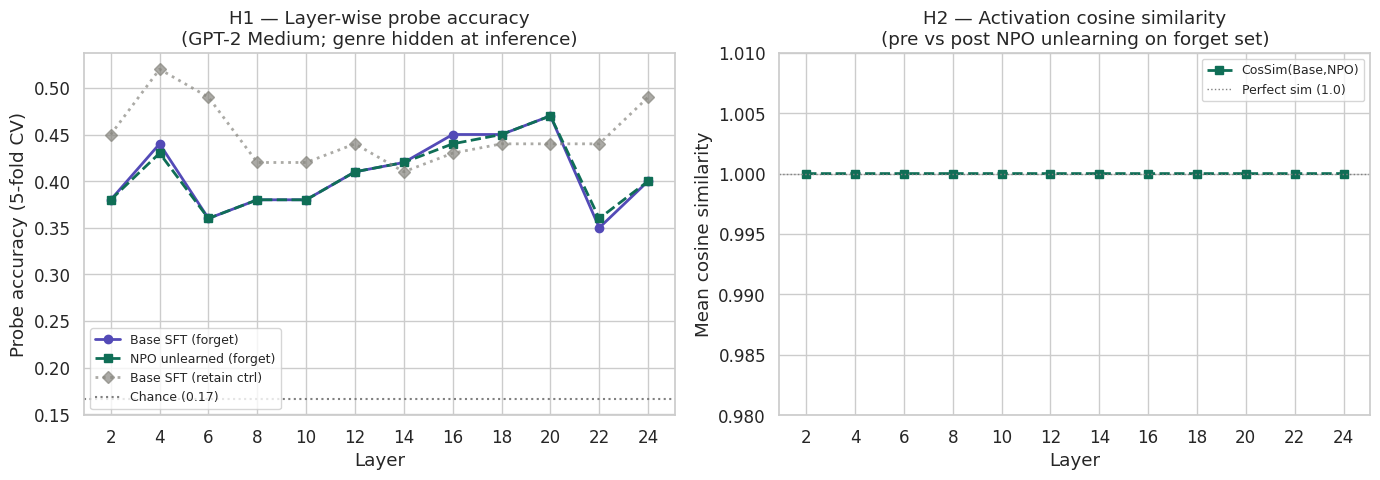

Saved: probe_cosim_npo.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
C      = {"Base":"#534AB7","NPO":"#0F6E56","Retain":"#888780"}
layers = sorted(PROBE_LAYERS)
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))

# ── Plot 1: probe accuracy ─────────────────────────────────────────────────────
ax1.plot(layers,[acc_base.get(l,0)   for l in layers],"o-", color=C["Base"],   lw=2,label="Base SFT (forget)")
ax1.plot(layers,[acc_npo.get(l,0)    for l in layers],"s--",color=C["NPO"],    lw=2,label="NPO unlearned (forget)")
ax1.plot(layers,[acc_retain.get(l,0) for l in layers],"D:", color=C["Retain"], lw=2,label="Base SFT (retain ctrl)",alpha=0.7)
ax1.axhline(CHANCE,ls=":",color="gray",lw=1.5,label=f"Chance ({CHANCE:.2f})")
ax1.set_xlabel("Layer"); ax1.set_ylabel("Probe accuracy (5-fold CV)")
ax1.set_title("H1 — Layer-wise probe accuracy\n(GPT-2 Medium; genre hidden at inference)")
ax1.legend(fontsize=9); ax1.set_xticks(layers)

yb = acc_base.get(DEEP,0); yn = acc_npo.get(DEEP,0)
if abs(yb-yn) > 0.005:
    ax1.annotate("",xy=(DEEP,yn),xytext=(DEEP,yb),
                 arrowprops=dict(arrowstyle="<->",color="red",lw=2))
    ax1.text(DEEP+0.2,(yb+yn)/2,f"\u0394={yb-yn:.3f}",fontsize=9,color="red",fontweight="bold")

# ── Plot 2: cosine similarity ──────────────────────────────────────────────────
ax2.plot(layers,[cosim_npo.get(l,0) for l in layers],"s--",color=C["NPO"],lw=2,label="CosSim(Base,NPO)")
ax2.axhline(1.0,ls=":",color="gray",lw=1,label="Perfect sim (1.0)")
ax2.set_xlabel("Layer"); ax2.set_ylabel("Mean cosine similarity")
ax2.set_title("H2 — Activation cosine similarity\n(pre vs post NPO unlearning on forget set)")
ax2.legend(fontsize=9); ax2.set_xticks(layers)
cs_vals = [v for v in cosim_npo.values() if v>0]
if cs_vals: ax2.set_ylim(max(0.85, min(cs_vals)-0.02), 1.01)

plt.tight_layout()
plt.savefig("/content/results/probe_cosim_npo.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved: probe_cosim_npo.png")


## Cell 15 — Divergence heatmap (H3)

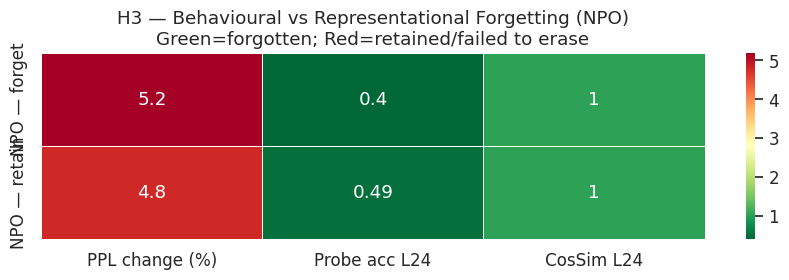

Saved: divergence_heatmap_npo.png


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns, pandas as pd

fig,ax = plt.subplots(figsize=(9,3))
rows = ["NPO — forget", "NPO — retain"]
cols = ["PPL change (%)", f"Probe acc L{DEEP}", f"CosSim L{DEEP}"]
data = [
    [round(npo_beh_f,1), safe(npo_deep,3), safe(npo_cs,4)],
    [round(npo_beh_r,1), safe(acc_retain.get(DEEP),3), 1.0],
]
hm = pd.DataFrame(data, index=rows, columns=cols)
sns.heatmap(hm, annot=True, fmt=".3g", cmap="RdYlGn_r", linewidths=0.5, ax=ax)
ax.set_title("H3 — Behavioural vs Representational Forgetting (NPO)\n"
             "Green=forgotten; Red=retained/failed to erase")
plt.tight_layout()
plt.savefig("/content/results/divergence_heatmap_npo.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved: divergence_heatmap_npo.png")


## Cell 16 — Save full results JSON

In [19]:
import json, math

def sf(v,n=4):
    if v is None or (isinstance(v,float) and math.isnan(v)): return None
    return round(float(v),n)

def verdict(base, post, chance, thr=0.05):
    if base is None or post is None: return "UNKNOWN"
    if math.isnan(base) or math.isnan(post): return "UNKNOWN"
    return "SUPPRESSION" if (base-post)<thr and post>chance+0.05 else "DELETION"

summary = {
    "model": MODEL_ID,
    "model_type": "GPT-2 Medium float32 full fine-tune (no quantisation)",
    "dataset": "MovieLens-1M",
    "forget_n": len(FORGET_USERS), "retain_n": len(RETAIN_USERS),
    "probe_layers": PROBE_LAYERS,  "num_genres": N_CLASSES,
    "chance_baseline": round(CHANCE,4),
    "unlearning_method": "NPO only (GA excluded — catastrophic collapse)",
    "perplexity": {
        "base_forget": sf(ppl_base_f,2), "npo_forget":  sf(ppl_npo_f,2),
        "base_retain": sf(ppl_base_r,2), "npo_retain":  sf(ppl_npo_r,2),
        "npo_forget_pct_change": sf(npo_beh_f,2),
        "npo_retain_pct_change": sf(npo_beh_r,2),
    },
    "probe_accuracy_deep_layer": {
        "layer": DEEP,
        "base": sf(acc_base.get(DEEP)),
        "npo":  sf(acc_npo.get(DEEP)),
    },
    "cosine_sim_deep_layer": {
        "layer": DEEP,
        "npo":  sf(cosim_npo.get(DEEP)),
    },
    "h1_verdict": "probe persists" if (acc_base.get(DEEP) or 0)>CHANCE+0.05 else "probe drops",
    "h3_npo_verdict": verdict(acc_base.get(DEEP), acc_npo.get(DEEP), CHANCE),
    "all_probe_acc": {
        "base":   {str(k):sf(v) for k,v in acc_base.items()},
        "npo":    {str(k):sf(v) for k,v in acc_npo.items()},
        "retain": {str(k):sf(v) for k,v in acc_retain.items()},
    },
    "all_cosim_npo": {str(k):sf(v) for k,v in cosim_npo.items()},
}

with open("/content/results/full_results.json","w") as f:
    json.dump(summary,f,indent=2)
print("Saved: /content/results/full_results.json")
print(json.dumps(summary,indent=2)[:2000])


Saved: /content/results/full_results.json
{
  "model": "gpt2-medium",
  "model_type": "GPT-2 Medium float32 full fine-tune (no quantisation)",
  "dataset": "MovieLens-1M",
  "forget_n": 100,
  "retain_n": 100,
  "probe_layers": [
    2,
    4,
    6,
    8,
    10,
    12,
    14,
    16,
    18,
    20,
    22,
    24
  ],
  "num_genres": 6,
  "chance_baseline": 0.1667,
  "unlearning_method": "NPO only (GA excluded \u2014 catastrophic collapse)",
  "perplexity": {
    "base_forget": 7.12,
    "npo_forget": 7.5,
    "base_retain": 7.37,
    "npo_retain": 7.72,
    "npo_forget_pct_change": 5.21,
    "npo_retain_pct_change": 4.8
  },
  "probe_accuracy_deep_layer": {
    "layer": 24,
    "base": 0.4,
    "npo": 0.4
  },
  "cosine_sim_deep_layer": {
    "layer": 24,
    "npo": 1.0
  },
  "h1_verdict": "probe persists",
  "h3_npo_verdict": "SUPPRESSION",
  "all_probe_acc": {
    "base": {
      "2": 0.38,
      "4": 0.44,
      "6": 0.36,
      "8": 0.38,
      "10": 0.38,
      "12": 0.41,

## Cell 17 — Download everything

In [21]:
import shutil, os
from google.colab import files

shutil.make_archive("/content/unlearning_v4_gpt2","zip","/content/results")
files.download("/content/unlearning_v4_gpt2.zip")
print("Download started.")
for f in sorted(os.listdir("/content/results")):
    size = os.path.getsize(f"/content/results/{f}")
    print(f"  {f:50s} {size/1024:.1f} KB")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
  divergence_heatmap_npo.png                         49.8 KB
  divergence_table.csv                               0.2 KB
  full_results.json                                  1.7 KB
  hidden_states.pkl                                  14402.4 KB
  probe_cosim_npo.png                                150.4 KB
  relearning_npo.png                                 90.3 KB
